# Homework #5

## Ensemble learning

This colaboratory contains Homework #5 of the Machine Learning course, which is due **November 16, midnight (23:59 EEST time)**. To complete the homework, extract **(File -> Download .ipynb)** and submit to the course webpage.

## Submission's rules:

1.  Please, submit only .ipynb that you extract from the Colaboratory.
2.  Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3.  Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4.  Please, make sure to avoid unnecessary long printouts.
5.  Each task should be solved right under the question of the task and not elsewhere.
6.  Solutions to both regular and bonus exercises should be submitted in one IPYNB file.

Please, steer clear of copying someone else's work. If you discuss assignments with anyone in the course, please, mention their names here:

Pooh


## List of Homework's exercises:

1.  [Ex1](#scrollTo=ux5PBYkbwewj) - 2 points
2.  [Ex2](#scrollTo=Z5C3GX9eXFF_) - 4 points
3.  [Ex3](#scrollTo=uHQscVCD7rM0) - 4 points
4.  [Bonus 1](#scrollTo=iJeG56t9-jWI) - 1 point
5.  [Bonus 2](#scrollTo=cLoHOqAcu0Q9) - up to 3 points
6.  [Bonus 3](#scrollTo=jdZkblZW7bEp) - up to 3 points (based on quality of presentation)


---

## Homework exercise 1: implement and train a bagging classifier with 3 K-NN models as estimators (2 points)

<font color=''> In this exercise you will need to use `classify_knn` function from the first practice session to train three different KNN models on three resamples of this dataset. </font>


In [255]:
import pandas as pd
import numpy as np

In [256]:
def create_random_2c_data (D, N):
  """
  Function create_random_2c_data generates two sets of D dimensional
  points (N points each), one for each class. The first set is sampled from D
  dimensional Gaussian distribution with mean 0 and standard deviation 1. The
  second set is generated from the distribution, with mean 1 and standard
  deviation 1.
  """
  # Generating N points for the first class
  mu_vec1 = np.zeros(D) # creates a vector of zeros, these are averages across each dimension
  cov_mat1 = np.eye(D) # creates a diagonal matrix of size D x D, all values except diagonal are 0
  class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, N)

  # The same stuff as above, just averages are shifted into 1
  mu_vec2 = np.ones(D) # creates a vector of ones
  cov_mat2 = np.eye(D)
  class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, N)

  # a lot of boring things....
  # gluing together two matrices generated above
  data = pd.DataFrame(np.concatenate((class1_sample, class2_sample)))

  # Create names for columns
  data.columns = [ 'x' + str(i) for i in (np.arange(D)+1)]

  # Create a class column
  data['class'] = np.concatenate((np.repeat(0, N), np.repeat(1, N)))

  # This is important for plotting and modelling
  data['class'] = data['class'].astype('category')

  return data

In [257]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
np.random.seed(2342347823) # random seed, this number was random, no need to build conspiracies around it

D = 2 # two dimensions
N = 100 # points per class

whole_data = create_random_2c_data(D, N)

# Randomly splitting data into train (60%) and validation (40%)
train, val = train_test_split(whole_data, random_state = 111, test_size = 0.40)

n_bootstraps = 3
np.random.seed(1111)

# creating resamples

# How to we control here the replace percentage, like how much data is duplicated?
resamples = [resample(train, n_samples = len(train), replace=True).index.values for i in range(n_bootstraps)]

# first resample
train_resample1 = train.loc[resamples[0]]

# second resample
train_resample2 = train.loc[resamples[1]]

# third resample
train_resample3 = train.loc[resamples[2]]

<font color=''> Here, I just convert pandas DataFrame into Numpy arrays that are easier to use list comprehension mechanisms on. </font>


In [258]:
train1 = np.asarray(train_resample1[['x1','x2']])
labels1 = np.asarray(train_resample1[['class']]).reshape((train_resample1.shape[0]))

train2 = np.asarray(train_resample2[['x1','x2']])
labels2 = np.asarray(train_resample2[['class']]).reshape((train_resample2.shape[0]))

train3 = np.asarray(train_resample3[['x1','x2']])
labels3 = np.asarray(train_resample3[['class']]).reshape((train_resample3.shape[0]))

val_points = np.asarray(val[['x1','x2']])
val_labels = np.asarray(val[['class']]).reshape((val.shape[0]))

<font color=''> **(Homework exercise 1- a)** Copy and adapt `classify_knn` function from the first homework and practice session to operate on 2D points. **(0.5 points)**</font>


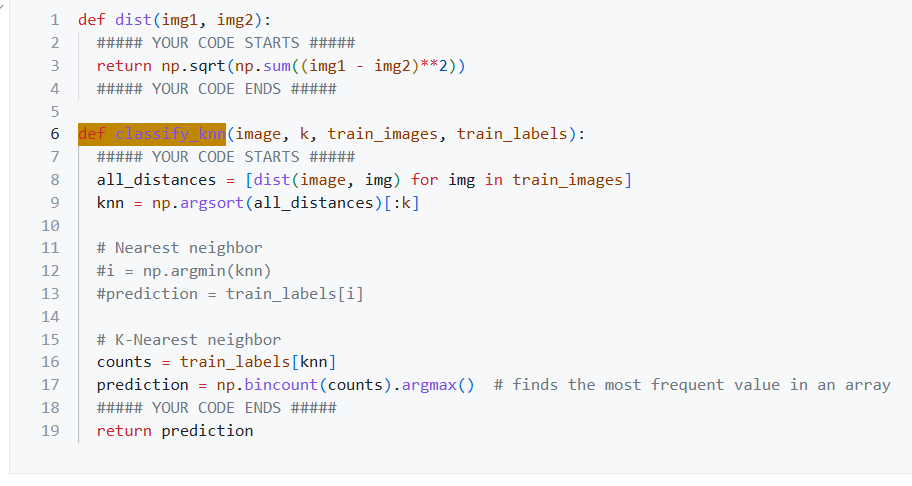

from 1st HW


In [259]:
def dist(point1, point2): # function dist is also from the first practice session
  # sum of squared coordinate-wise differences under sqrt
  return(np.sqrt(np.sum((point2 - point1)**2)))

def classify_knn(val_point, k, train, labels):

  ##### YOUR CODE STARTS #####
  all_distances = [dist(val_point, train_point) for train_point in train]
  nearest_neighbours = np.argsort(all_distances)[:k]
  predicted_classes = labels[nearest_neighbours]
  prediction = np.bincount(predicted_classes).argmax()
  ##### YOUR CODE ENDS #####

  return prediction

<font color=''> Test that the function was adapted correctly by running the following example </font>


In [260]:
val_point = val_points[1]
print(f'predicted class of the first point is {classify_knn(val_point, 5,  train1, labels1)}, while the true class is {val_labels[1]}')

predicted class of the first point is 0, while the true class is 0


<font color=''> **(Homework exercise 1- b)** Classify each point from the validation set using `classify_knn` function. Use different resamples and list comprehension. Fix `k` at 5. **(1 point)**</font>


In [261]:
k = 5

# Use three K-NN models that work on three different resamples

##### YOUR CODE STARTS #####
val['knn1'] = [classify_knn(val_point, k, train1, labels1) for val_point in val_points]
val['knn2'] = [classify_knn(val_point, k, train2, labels2) for val_point in val_points]
val['knn3'] = [classify_knn(val_point, k, train3, labels3) for val_point in val_points]
##### YOUR CODE ENDS #####

In [262]:
val.head()

,x1,x2,class,knn1,knn2,knn3
129,-1.440817,0.689593,1,0,1,0
79,-2.095889,-0.418547,0,0,0,0
126,-0.492024,0.490871,1,1,1,1
132,-0.197042,0.676853,1,1,0,0
35,0.217625,1.068660,0,1,1,0


<font color=''> Below aggregate individual predictions using the majority vote approach</font>


In [263]:
##### YOUR CODE STARTS #####


val['knn_bagging'] = val[['knn1', 'knn2', 'knn3']].mode(axis = 1)

##### YOUR CODE ENDS #####

print(f"Accuracy of hand made bagged ensemble with 3 KNNs is {np.sum(val['knn_bagging'] == val['class'])/len(val[['class']])*100}%")

Accuracy of hand made bagged ensemble with 3 KNNs is 66.25%


<font color=''> **(Homework exercise 1- c)** Use sklearn `BaggingClassifier` to implement analogous model that uses KNeighborsClassifier as an estimator (with k = 5). Don't forget to use a random state for reproducibility.

Assess its performance on the same validation set and display it. **(0.5 points)**</font>


In [264]:
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier

##### YOUR CODE STARTS #####
np.random.seed(seed := 1)
n_estimators_ = 3
n_neighbors_ = 5

knn_bagger = BaggingClassifier(
	estimator=KNeighborsClassifier(n_neighbors=n_neighbors_),
	n_estimators=n_estimators_,
	max_samples=0.8,  # max_samples 0.7-0.8 gave the best socre, but why?
	random_state=seed
)

knn_bagger.fit(train[['x1','x2']], train['class'])

##### YOUR CODE ENDS #####
print(f"Accuracy of sklearn bagging with {n_estimators_} KNNs {knn_bagger.score(val[['x1', 'x2']], val[['class']])*100}%")

Accuracy of sklearn bagging with 3 KNNs 75.0%


## Homework exercise 2: eXtreme Gradient Boosting (XGBoost) (4 points)

<font color=''> Let's finally build for ourselves a new shiny XGBoost model, the most popular algorithm for Kaggle competitions. </font>
<font color=''> Since XGBoost truly shines on tabular data, we are going to use the Thyroid Disease Dataset for training an XGboost model. Further details about this dataset can be found at
[here](https://www.openml.org/search?type=data&status=active&id=40475). </font>


In [68]:
from sklearn.datasets import fetch_openml

data = fetch_openml(name="thyroid-allhyper")

In [69]:
#Let's take a look at data
data.data

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26
0,41.0,1,1,1,1,1,1,1,1,1,...,2,1.30000,2,2.500000,2,125.0,2,1.140000,2,109.000000
1,23.0,1,1,1,1,1,1,1,1,1,...,2,4.10000,2,2.000000,2,102.0,1,0.997912,1,110.787984
2,46.0,2,1,1,1,1,1,1,1,1,...,2,0.98000,1,2.024966,2,109.0,2,0.910000,2,120.000000
3,70.0,1,2,1,1,1,1,1,1,1,...,2,0.16000,2,1.900000,2,175.0,1,0.997912,1,110.787984
4,70.0,1,1,1,1,1,1,1,1,1,...,2,0.72000,2,1.200000,2,61.0,2,0.870000,2,70.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,70.0,2,1,1,1,1,1,1,1,1,...,2,2.70000,1,2.024966,2,155.0,2,1.050000,2,148.000000
2796,73.0,2,1,2,1,1,1,1,1,1,...,1,4.67215,2,0.700000,2,63.0,2,0.880000,2,72.000000
2797,75.0,2,1,1,1,1,1,1,1,1,...,1,4.67215,1,2.024966,2,147.0,2,0.800000,2,183.000000
2798,60.0,1,1,1,1,1,1,1,1,1,...,2,1.40000,1,2.024966,2,100.0,2,0.830000,2,121.000000


In [70]:
# Types of classes
data.target

0       3
1       1
2       1
3       1
4       5
       ..
2795    5
2796    1
2797    1
2798    1
2799    5
Name: Class, Length: 2800, dtype: category
Categories (5, object): ['1', '2', '3', '4', '5']

In [71]:
# Number of instances for each class
data.target.value_counts()

Class
1    1632
5     771
3     275
2      91
4      31
Name: count, dtype: int64

<font color=''> **(Homework exercise 2- a)** Complete the preprocessing steps and train the XGBoost model for the Thyroid Disease classification task.
Find additional information regarding the training of an XGBoost model [here](https://xgboost.readthedocs.io/en/latest/python/python_intro.html) **(1.5 points)** </font>


In [72]:
!pip install xgboost

In [100]:
# Initial data preparation, which involves spliting the dataset into training, validation, and test sets
# Use 80/10/10 datasplit

##### YOUR CODE STARTS #####

X = data.data
y = data.target


# First split: Train (80%) and temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=0, stratify=y
)

# Second split: Validation (10%) and Test (10%) from the temp set
# temp is 20% of whole data -> each split gets 10%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=0, stratify=y_temp
)


y_train = y_train.cat.codes
y_val   = y_val.cat.codes
y_test  = y_test.cat.codes


print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

##### YOUR CODE ENDS #####

Train: (2240, 26) (2240,)
Validation: (280, 26) (280,)
Test: (280, 26) (280,)


In [101]:
y_train

2466    0
2074    2
742     0
1749    0
1154    2
       ..
1480    0
864     0
188     0
1846    2
1158    0
Length: 2240, dtype: int8

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

##### YOUR CODE STARTS #####

# XGBoost wants data to be wrapped into special formats
dtrain = xgb.DMatrix(data=X_train, label=y_train, enable_categorical=True)
dval = xgb.DMatrix(data=X_val, label=y_val, enable_categorical=True)
dtest = xgb.DMatrix(data=X_test, label=y_test, enable_categorical=True)

# Define the XGBoost parameters (you can add more parameters if you want)
# https://xgboost.readthedocs.io/en/latest/parameter.html
params = {
    "booster": "gbtree", #  Which booster to use. Can be gbtree, gblinear or dart; gbtree and dart use tree based models while gblinear uses linear functions.

    "eta": 0.3,  # Default=0.3, alias: learning_rate
	# Step size shrinkage used in update to prevent overfitting. After each boosting step, we can directly get the weights of new features, and eta shrinks the feature weights to make the boosting process more conservative.

    "objective": "multi:softmax",  # Specify the learning task and the corresponding learning objective. For multi-class classification, use "multi:softmax" or "multi:softprob".
    #   multi:softmax: set XGBoost to do multiclass classification using the softmax objective, you also need to set num_class(number of classes)

    #   multi:softprob: same as softmax, but output a vector of ndata * nclass, which can be further reshaped to ndata * nclass matrix. The result contains predicted probability of each data point belonging to each class.

    "num_class": len(y.unique()),  # Number of classes in the multi-class classification problem


    "eval_metric": "merror",  #  [default according to objective]
	# Evaluation metric for validation data,
    #   you can use "merror" for multi-class classification error rate
	#   or "mlogloss" for multi-class logloss.

    "seed": 1,
}

# Train for training and val for validation
eval_list = [(dtrain, 'train'), (dval, 'val')]

# Train the XGBoost model
# https://xgboost.readthedocs.io/en/latest/python/python_intro.html#training
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=500, # maximum number of boosting iterations (epochs)
    evals=eval_list,
    early_stopping_rounds=10,   # stop when val stops improving
    #verbose_eval=True
)

##### YOUR CODE ENDS #####

[0]	train-merror:0.30357	val-merror:0.31071
[1]	train-merror:0.28304	val-merror:0.31071
[2]	train-merror:0.27098	val-merror:0.30714
[3]	train-merror:0.25848	val-merror:0.31071
[4]	train-merror:0.24330	val-merror:0.32143
[5]	train-merror:0.23036	val-merror:0.30357
[6]	train-merror:0.21830	val-merror:0.30000
[7]	train-merror:0.21116	val-merror:0.32143
[8]	train-merror:0.20804	val-merror:0.32143
[9]	train-merror:0.20402	val-merror:0.32500
[10]	train-merror:0.19687	val-merror:0.32500
[11]	train-merror:0.19509	val-merror:0.32857
[12]	train-merror:0.19018	val-merror:0.33214
[13]	train-merror:0.18705	val-merror:0.32143
[14]	train-merror:0.18527	val-merror:0.33214
[15]	train-merror:0.18214	val-merror:0.32857


<font color=''> **(Homework exercise 2- b)** Make predictions on the test data and evaluate the model **(0.5 points)** </font>


In [118]:
##### YOUR CODE STARTS #####
test_pred = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))

test_pred_acc = accuracy_score(y_test, test_pred)

print(
	test_pred_acc
)
##### YOUR CODE ENDS #####

0.725


/gpfs/helios/home/etais/hpc_saskia/.conda/envs/the_standup_env/lib/python3.12/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Axes: >

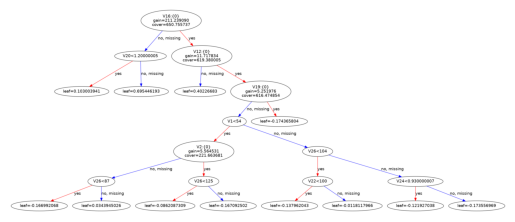

In [ ]:
xgb.plot_tree(bst, num_trees=2)

<font color=''> **(Homework exercise 2- c)** In machine learning, feature importance scores are used to determine the relative importance of each feature in a dataset when building a predictive model. Such scores can be derived from a variety of different models, including ensembles. Explore feature importance of the resulting XGBoost model and report the top five most important features **(0.5 points)** </font>


Top 5 most important features:
V1: 377.0
V18: 283.0
V24: 251.0
V26: 235.0
V22: 232.0


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

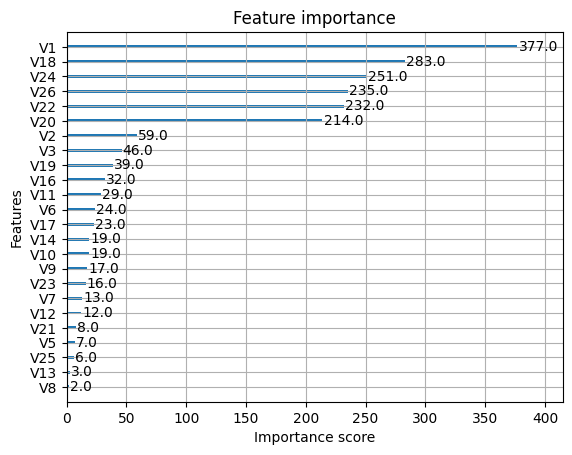

In [123]:
##### YOUR CODE STARTS #####

importance_dict = bst.get_score(importance_type="weight")  # number of times a feature is used in trees
top_features = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

print("Top 5 most important features:")
for feature, score in top_features[:5]:
    print(f"{feature}: {score}")

xgb.plot_importance(bst)

##### YOUR CODE ENDS #####

<font color=''> **(Homework exercise 2- d)** Train Adaptive Boosting, Gradient Boosting and a simple KNN model from sklearn (KNeighborsClassifier) on the same training data and evaluate on the same test data. For each model use the default hyperparameters (e.g. `n_estimators` or `n_neighbors`). If you do not want to use default parameters, you can use `cross_val_score` to pick the best values for the hyperparameters using training data. Compare the performance of these three models and XGBoost and draw conclusions in a separate text cell **(1.5 points)** </font>


In [134]:
%%time
# AdaBoostClassifier
##### YOUR CODE STARTS #####

from sklearn.ensemble import AdaBoostClassifier


ada_boost = AdaBoostClassifier()

ada_boost.fit(X_train, y_train)

test_pred_ada = ada_boost.predict(X_test)

print(
	f"Accuracy of AdaBoostClassifier is",
	f"{accuracy_score(y_test, test_pred_ada) * 100:.2f}%\n"
)

##### YOUR CODE ENDS #####

Accuracy of AdaBoostClassifier is 63.57%

CPU times: user 631 ms, sys: 1.82 ms, total: 633 ms
Wall time: 635 ms


In [137]:
%%time
# GradientBoostingClassifier
# might take considerable time if trained with default number of n_estimators
##### YOUR CODE STARTS #####

from sklearn.ensemble import GradientBoostingClassifier


gradient_boost = GradientBoostingClassifier()

gradient_boost.fit(X_train, y_train)

test_pred_gb = gradient_boost.predict(X_test)

print(
	f"Accuracy of GradientBoostingClassifier is",
	f"{accuracy_score(y_test, test_pred_gb) * 100:.2f}%\n"
)

##### YOUR CODE ENDS #####

Accuracy of GradientBoostingClassifier is 72.14%

CPU times: user 1.76 s, sys: 1.65 ms, total: 1.76 s
Wall time: 1.77 s


In [138]:
%%time
# KNeighborsClassifier
##### YOUR CODE STARTS #####

from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

test_pred_knn = knn.predict(X_test)

print(
	f"Accuracy of KNeighborsClassifier is",
	f"{accuracy_score(y_test, test_pred_knn) * 100:.2f}%\n"
)

##### YOUR CODE ENDS #####

Accuracy of KNeighborsClassifier is 57.86%

CPU times: user 146 ms, sys: 27.4 ms, total: 174 ms
Wall time: 38.6 ms


<font color=''> How these models compare with each other and to XGBoost? Can you try to elaborate on this difference? </font>


In [ ]:
# Write your comment here:

# XGBoost seems to perform the best out of the three classifiers tried here. It is likely due to its ability to handle complex relationships in the data through boosting, which combines multiple weak learners to create a strong predictive model. Additionally, XGBoost has built-in regularization techniques that help prevent overfitting, making it more robust on unseen data compared to the other classifiers.


## Homework exercise 3: Kaggle in-class to predict COVID-19 mortality (4 points)

<font color=''> In this exercise we will see how well ensembles work in the real-life problems. Here we are going to work with data from COVID-19 patients, and more specifically we will attempt to predict patient mortality based on clinical information. To this end, we have created a corresponding Kaggle in-class competition: https://www.kaggle.com/t/8367a0697a7e4d548af0c926d0335452 (this is invitation link). </font>

<font color=''> **(Homework exercise 3- a)** Getting started: follow the code provided with the Kaggle competition (`sample_notebook.ipynb`) to make the first sample submission using `random_predict` function, Kaggle API or by manually uploading submission file to https://www.kaggle.com/competitions/ml-ut-2024-covid-19-mortality-prediction. Report your score. **(0.5 points)** </font>


In [139]:
import pandas as pd
import numpy as np
import random

In [ ]:
#from google.colab import files
#files.upload();

<font color=''> Load `train.csv` and `test.csv` from https://www.kaggle.com/competitions/ml-ut-2024-covid-19-mortality-prediction


In [ ]:
#files.upload();

In [143]:
!pip install kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [kaggle]2m2/3 [kaggle]


In [151]:
!kaggle competitions download -c ml-ut-2025-covid-19-mortality-prediction -p ./data --force


  0%|                                                | 0.00/205k [00:00<?, ?B/s]
100%|████████████████████████████████████████| 205k/205k [00:00<00:00, 94.7MB/s]


['ml-ut-2025-covid-19-mortality-prediction.zip']

In [181]:
##### YOUR CODE STARTS #####
import zipfile
import pandas as pd

zip_path = './data/ml-ut-2025-covid-19-mortality-prediction.zip'
extract_dir = './data/covid_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

train = pd.read_csv(f'{extract_dir}/train.csv')
test = pd.read_csv(f'{extract_dir}/test.csv')

#train.head()
##### YOUR CODE ENDS #####

In [253]:
train

,DURACIÓN_HOSPITAL,ESTADO,MI,PVD,IC,CVD,DEMENT,EPOC,DMS,DMC,...,ALT,LEUCOCITOS,LINFOCITOS,IL6,FERRITINA,CRP,PROCALCITONINA,TROPONINA,NACIONALIDAD,FECHA_INGRESO
0,1,recuperado,0,0,0,0,0,0,0,0,...,14.0,5.6,1.4,NaN,NaN,0.4999,NaN,0.01,0,05-08-2020 03:32:01
1,2,fallecido,0,1,0,0,0,0,0,0,...,32.0,12.2,0.3,NaN,885.0,14.9000,0.6000,1.20,1,05-25-2020 11:15:37
2,2,fallecido,0,1,1,1,1,1,0,0,...,18.0,6.1,0.5,324.1000,629.0,33.9000,1.2000,NaN,1,05-11-2020 12:20:12
3,15,recuperado,1,0,0,0,1,0,0,1,...,17.0,3.7,0.5,NaN,816.0,18.4000,7.3000,0.05,0,05-23-2020 11:12:19
4,9,recuperado,0,0,0,0,0,0,0,0,...,28.0,5.7,1.4,39.4000,1691.0,11.6000,NaN,0.01,0,05-25-2020 01:44:55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3706,5,recuperado,0,1,0,0,0,0,0,0,...,27.0,8.0,2.3,3.9999,147.0,0.4999,0.0999,0.01,0,05-06-2020 04:49:14
3707,4,recuperado,0,0,0,0,0,0,0,0,...,24.0,10.3,1.0,NaN,295.0,1.8000,0.0999,0.01,2,05-02-2020 02:33:18
3708,2,recuperado,0,1,0,0,0,0,0,0,...,30.0,4.1,1.2,NaN,1165.0,3.1000,0.0999,0.01,3,05-01-2020 08:41:16
3709,0,recuperado,0,1,0,0,0,0,0,0,...,16.0,7.4,1.0,NaN,239.0,0.4999,0.0000,NaN,0,05-14-2020 02:35:59


<font color='red'> Insert your random guesser below:


In [154]:
##### YOUR CODE STARTS #####
def random_predict(test):
    return [random.choice(['recuperado', 'fallecido']) for _ in range(len(test))]
##### YOUR CODE ENDS #####

<font color='red'> Create a sample submission below


In [155]:
##### YOUR CODE STARTS #####
sample_submission = pd.DataFrame({'ID': list(range(0, len(test))), 'ESTADO': random_predict(test)})
sample_submission.to_csv('sample_submission.csv', index=False)
##### YOUR CODE ENDS #####

In [156]:
!kaggle competitions submit -c ml-ut-2025-covid-19-mortality-prediction -f sample_submission.csv -m "Sample submission test"

100%|██████████████████████████████████████| 14.1k/14.1k [00:00<00:00, 34.5kB/s]
Successfully submitted to ML@UT2025 COVID-19 Mortality Prediction

<font color=''> You can either use Kaggle API below to submit submission file or download file and submit it manually to Kaggle via web interface. </font>


<font color=''> You need to have an account on Kaggle.com, before you proceed. When you access your kaggle profile, you need to download your API Token from kaggle. It's very easy:

1. Click on your profile icon
2. Go to **Settings**
3. In **API** you press **Create new API token**

<font color=''> Now we load the file **kaggle.json** that you have downloaded, into this notebook: </font>


In [ ]:
#files.upload(); # upload your kaggle.json file

<font color=''> The next cell moves the file into a separate folder, sets secure access for it and configures your Kaggle profile for this notebook.</font>


In [ ]:
#import json

#!mkdir /root/.kaggle/
#!mv kaggle.json /root/.kaggle/kaggle.json
#!chmod 600 ~/.kaggle/kaggle.json
#!kaggle config set -n path -v{/content}

<font color=''> Assuming that you have accepted the rules of the competition, you should be able to make a submission using the following code: </font>


In [ ]:
#!kaggle competitions submit -c ml-ut-2024-covid-19-mortality-prediction -f sample_submission.csv -m "Random guess submission"

<font color=''> What was the score you received? Please add a screenshot from Kaggle that clearly shows your score. </font>


In [ ]:
# Report your result here:


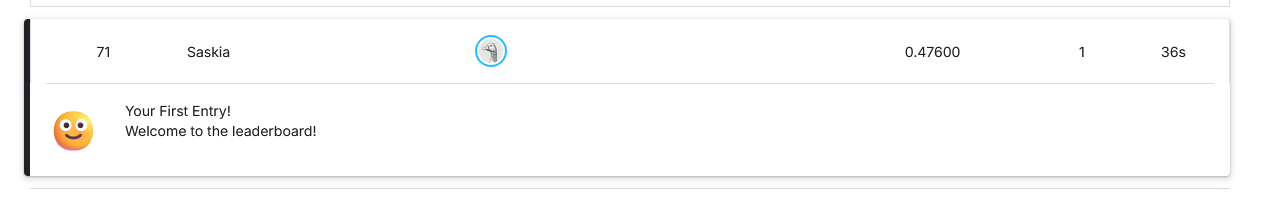


<font color=''> **(Homework exercise 3- b)** Take off: make two more submissions with at least two different ensemble models we have studied. Make sure to perform all necessary data pre-processing steps to accommodate the requirements of these ensemble models (e.g. data imputation and restructuring). To get full points, shortly summarise your pre-processing, models you have selected and rational behind this choice, and finally report your scores. **(2 points)** </font>


In [ ]:
# I used 3 models, because then it will break any ties when voting for the final prediction.

In [ ]:

X_train = train.drop(columns=['ESTADO', 'FECHA_INGRESO']) # FECHA_INGRESO - Date conversion issues, had to drop this column
y_train = train['ESTADO']

X_test = test.drop(columns=['FECHA_INGRESO']) # Date conversion issues, had to drop this column

In [ ]:
# 1. model - paralell models


In [ ]:
# 1.a - Bagging with Decision Trees

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

np.random.seed(1111)
n_estimators_ = 3

In [206]:
bagger = BaggingClassifier(
	estimator=DecisionTreeClassifier(),
	n_estimators=n_estimators_,
	max_samples=1.0,
	random_state=1111
)

bagger.fit(X, y)

,estimator,DecisionTreeClassifier()
,n_estimators,3
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,1111
,verbose,0


In [201]:
#print(f"Accuracy of sklearn bagging with {n_estimators_} Decision Trees {bagger.score(X_train, y_train)*100}%")

In [207]:
bagger_submission = pd.DataFrame(
	{
		'ID': list(range(0, len(X_test))),
		'ESTADO': bagger.predict(X_test)
	}
)
bagger_submission.to_csv('bagger.csv', index=False)

In [203]:
!kaggle competitions submit -c ml-ut-2025-covid-19-mortality-prediction -f bagger.csv -m "Bagger model with 3 decision trees"

100%|██████████████████████████████████████| 14.3k/14.3k [00:00<00:00, 29.5kB/s]
Successfully submitted to ML@UT2025 COVID-19 Mortality Prediction

In [244]:
# 1.b - Random forest

from sklearn.ensemble import RandomForestClassifier
np.random.seed(1111)
rf = RandomForestClassifier()

rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [245]:
rf_submission = pd.DataFrame(
	{
		'ID': list(range(0, len(X_test))),
		'ESTADO': rf.predict(X_test)
	}
)
rf_submission.to_csv('rf.csv', index=False)

In [246]:
!kaggle competitions submit -c ml-ut-2025-covid-19-mortality-prediction -f rf.csv -m "Random forest"

100%|██████████████████████████████████████| 14.4k/14.4k [00:00<00:00, 31.2kB/s]
Successfully submitted to ML@UT2025 COVID-19 Mortality Prediction

In [ ]:
# 1.c - Extreme random forest

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
np.random.seed(1111)


numeric_imputer = SimpleImputer(strategy='median') # mean

X_train_etf = numeric_imputer.fit_transform(X_train)
X_test_etf = numeric_imputer.transform(X_test)


etf = ExtraTreesClassifier()

etf.fit(X_train_etf, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [ ]:
etf_submission = pd.DataFrame(
	{
		'ID': list(range(0, len(X_test_etf))),
		'ESTADO': etf.predict(X_test_etf)
	}
)
etf_submission.to_csv('etf.csv', index=False)

In [270]:
!kaggle competitions submit -c ml-ut-2025-covid-19-mortality-prediction -f etf.csv -m "extreme random forest"

100%|██████████████████████████████████████| 14.4k/14.4k [00:00<00:00, 32.8kB/s]
Successfully submitted to ML@UT2025 COVID-19 Mortality Prediction

In [ ]:
# 2. model - sequential models


In [ ]:
# 2.a - AdaBoost

from sklearn.ensemble import AdaBoostClassifier
np.random.seed(1111)

X_train_ada = X_train.copy().dropna()
y_train_ada = y_train.copy()[X_train_ada.index]




ada_boost = AdaBoostClassifier(random_state=1111)

ada_boost.fit(X_train_ada, y_train_ada)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,1111


In [225]:
ada_submission = pd.DataFrame(
	{
		'ID': list(range(0, len(X_test))),
		'ESTADO': ada_boost.predict(X_test.copy().fillna(X_train_ada.mean()))
	}
)
ada_submission.to_csv('ada.csv', index=False)

In [226]:
!kaggle competitions submit -c ml-ut-2025-covid-19-mortality-prediction -f ada.csv -m "Ada boost"

100%|██████████████████████████████████████| 14.3k/14.3k [00:00<00:00, 31.5kB/s]
Successfully submitted to ML@UT2025 COVID-19 Mortality Prediction

In [ ]:
# 2.b - Gradient Boost machine

from sklearn.ensemble import GradientBoostingClassifier

X_train_gbm = X_train.copy().dropna()
y_train_gbm = y_train.copy()[X_train_gbm.index]


gbm = GradientBoostingClassifier(random_state=1111)

gbm.fit(X_train_gbm, y_train_gbm)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [232]:
gbm_submission = pd.DataFrame(
	{
		'ID': list(range(0, len(X_test))),
		'ESTADO': gbm.predict(X_test.copy().fillna(X_train_gbm.mean()))
	}
)
gbm_submission.to_csv('gbm.csv', index=False)

In [233]:
!kaggle competitions submit -c ml-ut-2025-covid-19-mortality-prediction -f gbm.csv -m "Gradient boost machine"

100%|██████████████████████████████████████| 14.3k/14.3k [00:00<00:00, 31.5kB/s]
Successfully submitted to ML@UT2025 COVID-19 Mortality Prediction

In [239]:
# 2.c - Stacking model

from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

X_train_stack = X_train.copy().dropna()
y_train_stack = y_train.copy()[X_train_stack.index]

np.random.seed(1111)
estimators = [('decision_tree', DecisionTreeClassifier()),
              ('knn', KNeighborsClassifier()),
              ('log_reg', LogisticRegression(max_iter=20000))]

stacking_classifier = StackingClassifier(estimators=estimators, final_estimator=SVC(), cv=5)
stacking_classifier.fit(X_train_stack, y_train_stack)


/gpfs/helios/home/etais/hpc_saskia/.conda/envs/the_standup_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 13029 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/gpfs/helios/home/etais/hpc_saskia/.conda/envs/the_standup_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 12808 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative s

,estimators,"[('decision_tree', ...), ('knn', ...), ...]"
,final_estimator,SVC()
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2


In [240]:
stack_submission = pd.DataFrame(
	{
		'ID': list(range(0, len(X_test))),
		'ESTADO': stacking_classifier.predict(X_test.copy().fillna(X_train_stack.mean()))
	}
)
stack_submission.to_csv('stack.csv', index=False)

In [241]:
!kaggle competitions submit -c ml-ut-2025-covid-19-mortality-prediction -f stack.csv -m "Stacking classifier"

100%|██████████████████████████████████████| 14.4k/14.4k [00:00<00:00, 33.1kB/s]
Successfully submitted to ML@UT2025 COVID-19 Mortality Prediction

In [287]:
stack_submission

,ID,ESTADO
0,0,recuperado
1,1,recuperado
2,2,recuperado
3,3,recuperado
4,4,recuperado
...,...,...
995,995,recuperado
996,996,recuperado
997,997,recuperado
998,998,recuperado


<font color=''> Summarise your pre-processing steps, models selected (why these?): </font>


In [ ]:
# Add your comment here:

# For sequential models i needed to handle missing data by removing rows with missing values from the training set and imputing missing values in the test set with the mean of the respective columns from the training set. This approach ensured that the models could be trained effectively without being affected by incomplete data.

# I selected these models because we tried them in previous assignments and they showed good performance on classification tasks.


<font color=''> Report scores of your two models and upload screenshots from Kaggle that clearly show each score </font>


In [ ]:
# Report your result here:

# For some reason paralell models performed better than sequential ones. The best performing model was the random forest from the pararell models, which achieved an accuracy of 71%.
# I would have tought that boosting models would perform better, since we have alot of data points, but they did not.

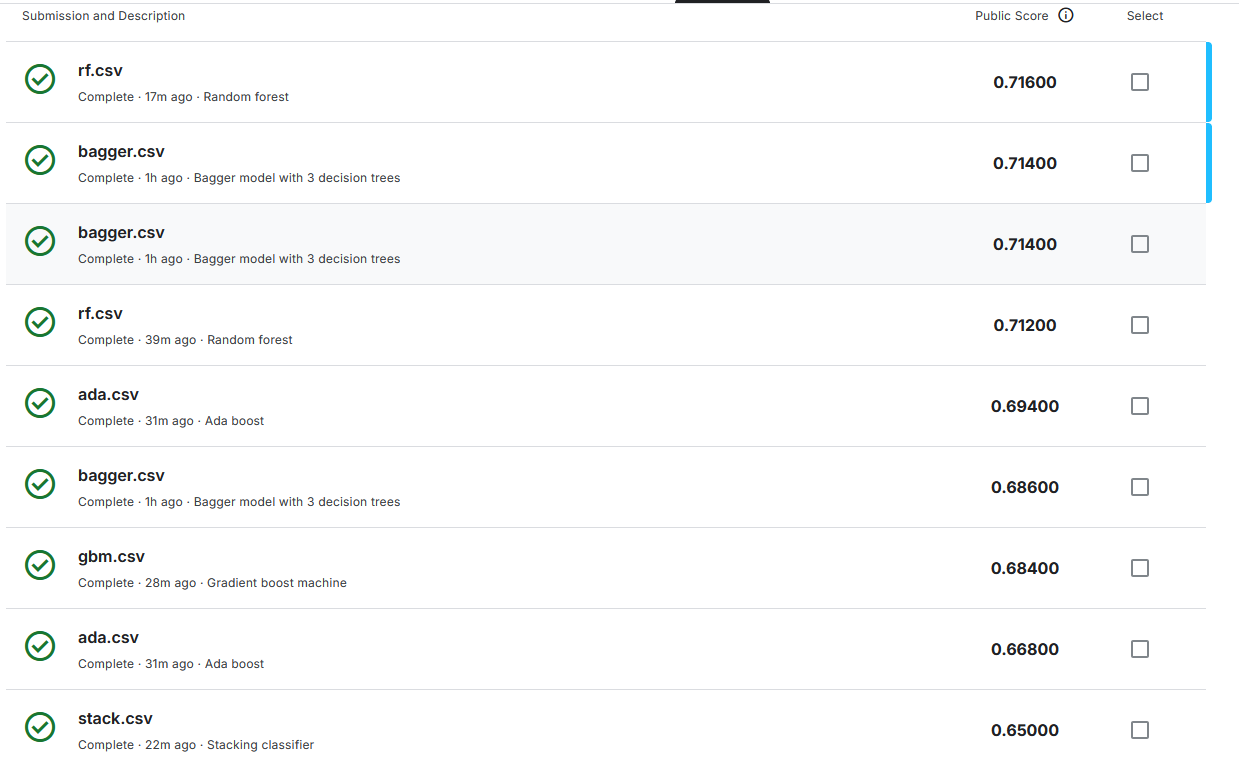


<font color=''> **(Homework exercise 3- c)** Reaching superiority: tune the above models or train a new one (does not have to be ensemble) such that you beat Ms.Smart (`ms_smart.csv`) benchmark. If one or both of your models from 3-b are already superior to Ms.Smart, then you should beat them instead. In order to claim the point in this exercise, describe the model, data pre-processing steps and report your score (which should be higher than Ms Smart's and your previous' models). **(1.5 points)** </font>


In [420]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import pandas as pd
import zipfile

zip_path = './data/ml-ut-2025-covid-19-mortality-prediction.zip'
extract_dir = './data/covid_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

train = pd.read_csv(f'{extract_dir}/train.csv')
test = pd.read_csv(f'{extract_dir}/test.csv')

le = LabelEncoder()
train['ESTADO'] = le.fit_transform(train['ESTADO'])


X_train = train.drop(columns=['ESTADO', 'FECHA_INGRESO'])
y_train = train['ESTADO']

X_test = test.drop(columns=['FECHA_INGRESO']) # Date conversion issues, had to drop this column

X_train.astype("float64")
X_test.astype("float64")


numeric_imputer = SimpleImputer(strategy='median') # mean

X_train = numeric_imputer.fit_transform(X_train)
X_test = numeric_imputer.transform(X_test)


In [421]:
##### YOUR CODE STARTS #####
import xgboost as xgb
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=1111)

dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval = xgb.DMatrix(X_val, label=y_val) # , enable_categorical=True
dtest = xgb.DMatrix(X_test)


watchlist = [(dtrain, "train"), (dval, "eval")]

params = {
    "booster": "gbtree",
    "objective": "multi:softmax",
    "num_class": len(le.classes_),
    "eval_metric": "merror",
    "seed": 67,
    "eta": 0.3,
	"validate_parameters": True,
}

bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=watchlist,
    early_stopping_rounds=50,  # stops if eval error doesn’t improve for 50 rounds
    verbose_eval=50
)

##### YOUR CODE ENDS #####

[0]	train-merror:0.13237	eval-merror:0.12366


[50]	train-merror:0.00240	eval-merror:0.10215
[72]	train-merror:0.00000	eval-merror:0.10484


In [422]:
val_pred = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
val_acc = (val_pred == y_val).mean()
print("Validation accuracy:", val_acc)


Validation accuracy: 0.9032258064516129


In [423]:
pred = le.inverse_transform(bst.predict(dtest).astype(int))

In [424]:
submission = pd.DataFrame(
	{
		'ID': list(range(0, len(pred))),
		'ESTADO': pred
	}
)
submission.to_csv('xgboost_2.csv', index=False)

In [425]:
submission

,ID,ESTADO
0,0,recuperado
1,1,recuperado
2,2,recuperado
3,3,fallecido
4,4,fallecido
...,...,...
995,995,fallecido
996,996,fallecido
997,997,fallecido
998,998,recuperado


In [426]:
!kaggle competitions submit -c ml-ut-2025-covid-19-mortality-prediction -f xgboost_2.csv -m "XGBoost v2 model"

100%|██████████████████████████████████████| 14.3k/14.3k [00:00<00:00, 34.5kB/s]
400 Client Error: Bad Request for url: https://www.kaggle.com/api/v1/competitions/submissions/submit/ml-ut-2025-covid-19-mortality-prediction


In [286]:
xgb_submission

,ID,ESTADO
0,0,recuperado
1,1,recuperado
2,2,recuperado
3,3,fallecido
4,4,fallecido
...,...,...
995,995,recuperado
996,996,recuperado
997,997,fallecido
998,998,recuperado


<font color=''> Summarise your pre-processing steps, models selected (why these?), and the "special sauce" (what you changed compared to 3-b) below: </font>


In [ ]:
# Add your comment here:


# I added missing data with median(/median) imputation (both mean and median worked equally well), because it worked well in previous assignments.
# I encoded the target variable using label encoding to convert the categorical labels into numerical format, which is required for the XGBoost model to process the data effectively.

# I had to drop FECHA_INGRESO column due to date conversion issues

# I set the learning rate (eta) to 0.3 or (0.1) to allow the model to learn quickly from the data, which can be beneficial when dealing with a large dataset.


# What i changed in the model compared to previous excersise:
# - started using XGB instead of random forest and bagging which had better results in previous exercise.
# 	for some reason in previous excersise paralell models performed better than sequential ones, but it think its because I dropped NaN values in sequential models and i didnt map string (categorical) values to numbers correctly.

# NB! One big reason i got better score was also playing around with random seed, because some seeds just worked better than others.
# 	with seed 1111 I got 72% but with seed 67 i got 74% on the same XGBoost model.

<font color=''> What was the score you received? Please add a screenshot from Kaggle that clearly shows your score. </font>


In [ ]:
# Add your comment here:


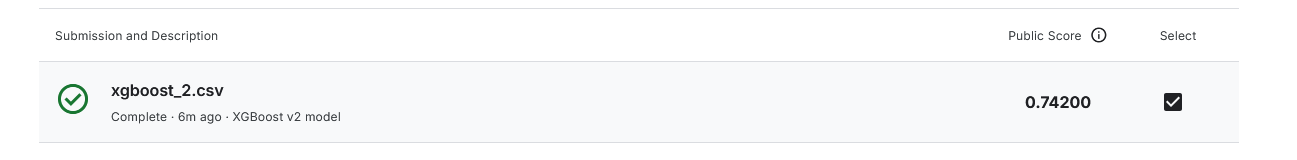


# Bonus exercises

_(NB, these are optional exercises!)_


## Bonus exercise 1 (1 bonus point): Interim Champion


<font color='red'> If at any point of time your submission lended at the top of the **public leaderboard** from the Kaggle competition (Exercise 3), take a screenshot of this achievement before it is too late and somebody else did not knock it off. Post this screenshot below (add a picture). Describe your solution below (do not have to write too much, just the main idea). You can only get this point once.


In [ ]:
# Add your comment here:


## Bonus exercise 2 (up to 3 bonus points): Top Perfomer Challenge


<font color='red'> You are encouraged to compete for the top three places in the Kaggle competition described in Exercise 3. So, **3 points** for the first place, **2 points** for the second place and **1.5 points** for the third place.

<font color='red'> To receive the bonus points, you must finish in the top three of the **private leaderboard**. The end of the competition is 17.11.2024 23:59:59.
Remember that you can make only **10 submissions per day**, so start early.</font>


## Bonus exercise 3 (up to 3 bonus points depending on presentation): Discrete AdaBoost from scratch


<font color='red'> In the class we have discussed a simplified version of the AdaBoost, the goal of this task is to implement an unabrdiged version of the Discrete AdaBoost classifier following the instructions from the paper [Friedman et al (2000)](https://hastie.su.domains/Papers/AdditiveLogisticRegression/alr.pdf). In a nutshell, AdaBoost classifier assigns initial weights to training examples, fits a weak classifier, and updates the data and classifier weights based on classification accuracy. The process is repeated for each weak estimator. The final strong classifier combines weak classifiers with different weights.</font>


<font color='red'> Implement AdaBoost classifier.

Tips:

-   use `DecisionTreeClassifier` from `sklearn` as a weak classifier
-   avoid division by zero
-   pay attention to the format of data labels.</font>


In [ ]:
class AdaBoost:
  def __init__(self, n_estimators=50):
    self.n_estimators = n_estimators
    self.estimator_weights = []
    self.models = []

  def fit(self, X, y):
    ##### YOUR CODE STARTS #####
    ...
    ##### YOUR CODE ENDS #####

  def predict(self, X):
    ##### YOUR CODE STARTS #####
    ...
    ##### YOUR CODE ENDS #####


<font color='red'> Test your model on the dataset from exercise 3. Report accuracy on the test set and observe how the performance changes with the different number of estimators.</font>


In [ ]:
##### YOUR CODE STARTS #####
...
##### YOUR CODE ENDS #####

<font color='red'> Use sklearn implementation of AdaBoost classifier with the same parameters as you used for your implementation. Report accuracy on the test set as well. </font>


In [ ]:
##### YOUR CODE STARTS #####
...
##### YOUR CODE ENDS #####

<font color='red'> Report difference in results, if there are any. Explain why sklearn's model behaves differently, you might want to take a look at sklearn's [code](https://github.com/scikit-learn/scikit-learn/blob/093e0cf14/sklearn/ensemble/_weight_boosting.py#L341) :)</font>


<font color='red'> Your answer:</font>


# Comments (optional feedback to the course instructors)

Here, please, leave your comments regarding the practice session, possibly answering the following questions:

-   how much time did you spend on this homework?
-   was it too hard/easy for you?
-   what would you suggest to add or remove?
-   anything else you would like to tell us


Your comments:


# <font color='red'> End of the homework. Please don't delete this cell.</font>
